# Modelo de precio de venta

Estima cuánto **debería** valer una propiedad según sus características, y compara esa estimación
con el precio que pide el aviso para decir si está **barata, en precio de mercado o cara**.

Es la primera de las dos piezas del análisis de inversión. La segunda —cuánto se podría arrendar—
usa el mismo dataset y las mismas variables, y se construye después.

## Marco teórico: el modelo hedónico

Se sigue el marco que revisa Owusu-Ansah (2011), *A Review of Hedonic Pricing Models in Housing
Research*.

**La idea de Rosen (1974)**, que el artículo toma como fundamento, es que una vivienda no se compra
como un objeto único sino como un **paquete de atributos**. El precio observado revela los *precios
implícitos* de cada atributo: cuánto vale un metro cuadrado más, un baño más, estar a 300 metros del
metro en vez de a 1.200. Como esos precios no se transan por separado, se estiman por regresión.

El artículo agrupa los atributos en **tres bloques**, y nuestro dataset tiene los tres:

| Bloque | Qué es | Nuestras variables |
|---|---|---|
| **Estructural** | La propiedad en sí | `m2_util`, `m2_total`, `dormitorios`, `banos`, `estacionamientos`, `bodegas`, `antiguedad` |
| **Ubicación** | Dónde está | `lat`, `lon`, `comuna`, `barrio` |
| **Vecindario** | Qué hay alrededor | Las 7 categorías de `servicios_cercanos`: metro, salud, comercio, universidad, educación, parque, supermercado |

### La forma funcional

El artículo describe la forma **semi-logarítmica** como la más empleada:

$$\ln Y_i = \beta_0 + \beta_1 X_i + \beta_2 Z_i + u_i$$

donde $Y$ es el precio, $X$ las características de la vivienda y $Z$ las de ubicación (latitud y
longitud). Citando a Follain y Malpezzi (1980), señala tres ventajas:

1. Los coeficientes se leen como **cambio porcentual del precio** ante un cambio unitario del atributo.
2. Permite que el valor monetario de cada característica varíe según el nivel de precio.
3. **Reduce la heterocedasticidad.**

Por eso todos los modelos de aquí se entrenan sobre `log(precio_uf)` y se exponencian al predecir.

### Por qué además usamos árboles y no solo la regresión

El artículo concluye que los modelos **paramétricos** son fáciles de estimar e interpretar pero
*imponen supuestos fuertes que pueden dar resultados engañosos cuando se violan*; los **no
paramétricos** evitan esos supuestos pero *son computacionalmente técnicos y complicados*.

El gradient boosting cae del lado no paramétrico: no asume ninguna forma funcional, captura
interacciones (que 60 m² valen distinto en Ñuñoa que en La Florida) y no exige linealidad. Lo que
el artículo señala como su costo —la pérdida de interpretabilidad— se recupera con SHAP, que
devuelve la contribución de cada atributo igual que un coeficiente hedónico.

Se incluye igualmente una **regresión log-lineal (Ridge)** como referencia: es el modelo del
artículo, y sirve de piso contra el cual medir si la flexibilidad de los árboles aporta algo.

In [1]:
import json
import sqlite3
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

SEMILLA = 42
ANIO = 2026
DB = Path("data/ofertas_unificado.sqlite")
MODELOS = Path("modelos"); MODELOS.mkdir(exist_ok=True)
COLORES = ["#0A6B67", "#8A3E5C", "#C08A2E", "#3B6EA5", "#6B7A3E"]
print(f"pandas {pd.__version__} · numpy {np.__version__}")

pandas 3.0.5 · numpy 2.5.2


## Paso 1 — Carga y limpieza

La misma limpieza que se validó en el notebook de clustering: el centinela `SIN_DATO` a `NaN`, los
campos de antigüedad que venían intercambiados, los precios sin convertir, y los valores imposibles
anulados sin descartar la fila.

In [2]:
with sqlite3.connect(f"file:{DB.as_posix()}?mode=ro", uri=True, timeout=15) as con:
    crudo = pd.read_sql_query("SELECT * FROM ofertas WHERE operacion='venta'", con)

df = crudo.replace("SIN_DATO", pd.NA)
NUMERICAS = ["precio_uf", "precio_clp", "m2_util", "m2_total", "dormitorios", "banos",
             "estacionamientos", "bodegas", "ano_construccion", "antiguedad_anos",
             "gastos_comunes_clp", "lat", "lon"]
for c in NUMERICAS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
print(f"venta: {len(df):,} avisos")

# --- Reparaciones (recuperan dato, no lo descartan) --------------------------
swap = df["ano_construccion"].between(0, 60) & df["antiguedad_anos"].between(1900, 2030)
df.loc[swap, ["ano_construccion", "antiguedad_anos"]] = \
    df.loc[swap, ["antiguedad_anos", "ano_construccion"]].to_numpy()

ambos = df["precio_clp"].notna() & df["precio_uf"].notna() & (df["precio_uf"] > 0)
UF = float((df.loc[ambos, "precio_clp"] / df.loc[ambos, "precio_uf"]).median())
falta = df["precio_uf"].isna() & df["precio_clp"].notna()
df.loc[falta, "precio_uf"] = df.loc[falta, "precio_clp"] / UF
print(f"  campos de antiguedad intercambiados, reparados : {int(swap.sum()):,}")
print(f"  precios reconstruidos con UF = {UF:,.2f}          : {int(falta.sum()):,}")

# --- Anulaciones (valor imposible, la fila se conserva) ----------------------
RANGOS = {"estacionamientos": (0, 10), "bodegas": (0, 10), "dormitorios": (0, 10),
          "banos": (1, 12), "ano_construccion": (1900, 2030),
          "gastos_comunes_clp": (0, 3_000_000)}
for col, (lo, hi) in RANGOS.items():
    df.loc[df[col].notna() & ~df[col].between(lo, hi), col] = np.nan
df.loc[df["m2_total"].notna() & (df["m2_util"] > df["m2_total"]), "m2_total"] = np.nan
df.loc[(df["tipo"] == "departamento") & (df["gastos_comunes_clp"] == 0),
       "gastos_comunes_clp"] = np.nan

# --- Filtro final de rango: lo unico que descarta filas ----------------------
antes = len(df)
df = df[df["precio_uf"].between(500, 60_000) & df["m2_util"].between(20, 800)].copy()
print(f"\ntras el filtro de rango: {len(df):,} avisos (se descartan {antes-len(df)})")
print(f"  {df['tipo'].value_counts().to_dict()}")
print(f"  precio mediano: {df['precio_uf'].median():,.0f} UF")

venta: 9,973 avisos
  campos de antiguedad intercambiados, reparados : 119
  precios reconstruidos con UF = 40,844.79          : 1,193

tras el filtro de rango: 9,812 avisos (se descartan 161)
  {'departamento': 6730, 'casa': 3082}
  precio mediano: 3,902 UF


## Paso 2 — Las variables, en los tres bloques de Rosen

El JSON de `servicios_cercanos` se abre en columnas numéricas: para cada una de las siete
categorías, la **distancia al más cercano** y **cuántos hay en un kilómetro**.

Sobre esas dos: la distancia es **exacta** —la API devuelve los lugares ordenados por cercanía, así
que el más próximo nunca queda fuera—, pero el conteo está **censurado** en las zonas densas, donde
los 20 resultados de la consulta se llenaron. Por eso se incluye `servicios_truncado`: el modelo
necesita saber cuándo el conteo es un piso y no el total.

In [3]:
CATEGORIAS_POI = ["metro", "salud", "comercio", "universidad",
                  "educacion", "parque", "supermercado"]


def abrir_servicios(serie):
    """El JSON de servicios_cercanos -> columnas numericas."""
    filas = []
    for s in serie:
        d = {}
        if isinstance(s, str) and s not in ("", "SIN_DATO"):
            j = json.loads(s)
            for cat in CATEGORIAS_POI:
                v = j.get(cat)
                d[f"dist_{cat}_m"] = v["mas_cercano_m"] if v else np.nan
                d[f"n_{cat}_1km"] = v["n_1km"] if v else np.nan
            d["servicios_truncado"] = float(j.get("_truncado", False))
        else:
            for cat in CATEGORIAS_POI:
                d[f"dist_{cat}_m"] = np.nan
                d[f"n_{cat}_1km"] = np.nan
            d["servicios_truncado"] = np.nan
        filas.append(d)
    return pd.DataFrame(filas, index=serie.index)


def construir_features(d):
    """Las tres familias de atributos del marco hedonico."""
    d = d.copy()
    dorm = d["dormitorios"].fillna(1).clip(lower=1)

    # --- estructurales ---
    d["antiguedad"] = ANIO - d["ano_construccion"]
    d["log_m2_util"] = np.log(d["m2_util"])
    d["ratio_terraza"] = ((d["m2_total"] - d["m2_util"]) / d["m2_total"]).where(
        d["m2_total"].notna() & (d["m2_total"] > 0))
    d["m2_por_dormitorio"] = d["m2_util"] / dorm
    d["densidad_banos"] = d["banos"] / dorm
    d["es_casa"] = (d["tipo"] == "casa").astype(float)
    d["tiene_estacionamiento"] = (d["estacionamientos"].fillna(0) > 0).astype(float)
    d["tiene_bodega"] = (d["bodegas"].fillna(0) > 0).astype(float)

    # --- vecindario ---
    d = pd.concat([d, abrir_servicios(d["servicios_cercanos"])], axis=1)
    # El logaritmo de la distancia captura mejor el efecto: pasar de 100 a 300 m
    # del metro pesa mucho mas que pasar de 1.100 a 1.300 m.
    for cat in CATEGORIAS_POI:
        d[f"log_dist_{cat}"] = np.log1p(d[f"dist_{cat}_m"])
    return d


datos = construir_features(df)

ESTRUCTURALES = ["m2_util", "log_m2_util", "m2_total", "ratio_terraza", "dormitorios",
                 "banos", "densidad_banos", "m2_por_dormitorio", "estacionamientos",
                 "bodegas", "tiene_estacionamiento", "tiene_bodega", "antiguedad",
                 "gastos_comunes_clp", "es_casa"]
UBICACION_NUM = ["lat", "lon"]
UBICACION_CAT = ["comuna"]
VECINDARIO = ([f"log_dist_{c}" for c in CATEGORIAS_POI]
              + [f"n_{c}_1km" for c in CATEGORIAS_POI] + ["servicios_truncado"])

NUM = ESTRUCTURALES + UBICACION_NUM + VECINDARIO
TODAS = NUM + UBICACION_CAT

# El precio no puede entrar como predictor bajo ninguna forma
PROHIBIDAS = {"precio_uf", "precio_clp", "precio_valor", "antiguedad_aviso_dias",
              "fecha_publicacion", "uf_por_m2"}
assert not set(TODAS) & PROHIBIDAS, "hay una columna prohibida entre las features"

print(f"{len(TODAS)} variables en tres bloques:")
print(f"  estructurales : {len(ESTRUCTURALES):>2}")
print(f"  ubicacion     : {len(UBICACION_NUM)+len(UBICACION_CAT):>2}")
print(f"  vecindario    : {len(VECINDARIO):>2}")
print("\n% de valores faltantes por bloque:")
for nombre, cols in [("estructurales", ESTRUCTURALES), ("ubicacion", UBICACION_NUM),
                     ("vecindario", VECINDARIO)]:
    print(f"  {nombre:<14} {100*datos[cols].isna().mean().mean():.1f}%")

33 variables en tres bloques:
  estructurales : 15
  ubicacion     :  3
  vecindario    : 15

% de valores faltantes por bloque:
  estructurales  10.9%
  ubicacion      0.5%
  vecindario     1.7%


## Paso 3 — La división 80/20

80 % para entrenar, 20 % para evaluar. Pero **no dividido al azar por filas**, y la razón es
concreta: en este dataset **el 62 % de los avisos comparte coordenada exacta con otro** porque son
departamentos del mismo edificio. Hay puntos con hasta 104 avisos.

Con una división aleatoria, casi toda torre grande queda partida entre entrenamiento y prueba. El
modelo podría aprender el precio de esa torre en concreto y repetirlo en la prueba: acertar por
memoria y no por haber entendido el mercado.

Por eso el 80/20 se hace **agrupando por edificio** (coordenada redondeada a ~11 m): cada edificio
cae entero de un lado o del otro. En el Paso 6 se mide qué habría pasado con la división aleatoria,
para saber si esa precaución era necesaria o no — que es una pregunta empírica, no una certeza.

In [4]:
datos = datos.reset_index(drop=True)

# Identificador de edificio: coordenada a 4 decimales (~11 m). Sin geo, cae a la
# direccion normalizada y, si tampoco hay, a un identificador propio.
geo_ok = datos["lat"].notna() & datos["lon"].notna()
grupo = pd.Series(index=datos.index, dtype="object")
grupo[geo_ok] = ("g:" + datos.loc[geo_ok, "lat"].map("{:.4f}".format)
                 + "," + datos.loc[geo_ok, "lon"].map("{:.4f}".format))
sin_geo = ~geo_ok
if sin_geo.any():
    dirs = datos.loc[sin_geo, "direccion"].fillna("").str.lower().str.strip()
    grupo[sin_geo] = np.where(dirs != "", "d:" + dirs,
                              [f"u:{i}" for i in datos.index[sin_geo]])
datos["edificio"] = grupo

y = datos["precio_uf"].to_numpy(float)
X = datos[TODAS]

separador = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEMILLA)
i_train, i_test = next(separador.split(X, y, groups=datos["edificio"]))

# Version aleatoria, solo para comparar despues
i_train_al, i_test_al = train_test_split(np.arange(len(X)), test_size=0.20,
                                         random_state=SEMILLA)

print(f"total          : {len(X):,} avisos en {datos['edificio'].nunique():,} edificios\n")
print(f"ENTRENAMIENTO  : {len(i_train):,} ({100*len(i_train)/len(X):.1f}%)")
print(f"PRUEBA         : {len(i_test):,} ({100*len(i_test)/len(X):.1f}%)")

cruce = set(datos.loc[i_train, "edificio"]) & set(datos.loc[i_test, "edificio"])
print(f"\nedificios que aparecen en ambos lados: {len(cruce)}   "
      f"{'CORRECTO' if not cruce else 'HAY FUGA'}")
cruce_al = set(datos.loc[i_train_al, "edificio"]) & set(datos.loc[i_test_al, "edificio"])
print(f"   con division aleatoria serian: {len(cruce_al):,}  <- por eso no se usa")

print(f"\nprecio mediano  train {np.median(y[i_train]):>7,.0f} UF   "
      f"test {np.median(y[i_test]):>7,.0f} UF")

total          : 9,812 avisos en 6,279 edificios

ENTRENAMIENTO  : 7,852 (80.0%)
PRUEBA         : 1,960 (20.0%)

edificios que aparecen en ambos lados: 0   CORRECTO
   con division aleatoria serian: 661  <- por eso no se usa

precio mediano  train   3,900 UF   test   4,031 UF


## Paso 4 — Cómo se mide

Las métricas del estándar de tasación masiva (IAAO), no las habituales de ML. En tasación se usa la
**mediana** y no el promedio porque unas pocas propiedades atípicas distorsionan cualquier media.

| Métrica | Qué mide | Referencia |
|---|---|---|
| **MdAPE** | Error porcentual absoluto mediano | < 15 % bueno, < 10 % excelente |
| **PPE10** | % de estimaciones dentro de ±10 % | > 50 % |
| **COD** | Uniformidad: dispersión de los ratios | 5 – 15 |
| **PRD** | Sesgo vertical: ¿sobrevalora las baratas? | 0,98 – 1,03 |

Todas se calculan en **UF**, nunca en logaritmos: un R² de 0,9 sobre `log(precio)` puede esconder un
error enorme en dinero.

In [5]:
def evaluar(y_real, y_pred):
    y, p = np.asarray(y_real, float), np.asarray(y_pred, float)
    ok = np.isfinite(y) & np.isfinite(p) & (y > 0)
    y, p = y[ok], p[ok]
    ape = 100 * np.abs(p - y) / y
    r = p / y
    med = np.median(r)
    return {
        "n": len(y),
        "MdAPE": float(np.median(ape)),
        "PPE10": float(100 * np.mean(ape <= 10 + 1e-9)),
        "PPE20": float(100 * np.mean(ape <= 20 + 1e-9)),
        "COD": float(100 * np.mean(np.abs(r - med)) / med),
        "PRD": float(np.mean(r) / (p.sum() / y.sum())),
        "R2": float(1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum()),
        "MAE_UF": float(np.mean(np.abs(p - y))),
    }


# Verificacion con un caso de valor conocido: cuatro errores de exactamente 10%
_c = evaluar([100, 200, 300, 400], [110, 180, 330, 360])
assert abs(_c["MdAPE"] - 10) < 1e-9 and abs(_c["PPE10"] - 100) < 1e-9
print(f"metricas verificadas con el caso canonico: MdAPE {_c['MdAPE']:.1f} · "
      f"PPE10 {_c['PPE10']:.0f} · COD {_c['COD']:.1f} · PRD {_c['PRD']:.4f}")

metricas verificadas con el caso canonico: MdAPE 10.0 · PPE10 100 · COD 10.0 · PRD 1.0204


## Paso 5 — Los modelos

Todos comparten la misma estructura de tres capas, y esa envoltura resuelve un problema de raíz:

```
TransformedTargetRegressor(log / exp)   <- predict() devuelve UF, nunca logaritmos
  Pipeline
    ColumnTransformer                   <- imputa y codifica, ajustado SOLO con el train
    estimador
```

Que la imputación viva dentro del pipeline no es un detalle de estilo: si se imputara antes de
dividir, la mediana del conjunto de prueba se filtraría al de entrenamiento.

**Ridge** es el modelo del artículo, la regresión log-lineal. **Los árboles** no asumen forma
funcional. La comparación dice si esa flexibilidad aporta algo real.

Un detalle sobre la retransformación: `exp(media de logaritmos)` estima la **mediana** condicional,
no la media. Es exactamente lo que miden MdAPE y PPE10, así que no se aplica corrección de smearing
—hacerlo mejoraría el sesgo en media y empeoraría la métrica que nos importa.

In [6]:
def preprocesador(imputar_y_escalar):
    """imputar_y_escalar=True para modelos lineales; False deja el NaN a los arboles."""
    if imputar_y_escalar:
        pipe_num = Pipeline([("imputar", SimpleImputer(strategy="median", add_indicator=True)),
                             ("escalar", StandardScaler())])
    else:
        pipe_num = "passthrough"
    return ColumnTransformer(
        [("num", pipe_num, NUM),
         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), UBICACION_CAT)],
        remainder="drop")   # nada entra por accidente


def envolver(estimador, imputar):
    interno = Pipeline([("prep", preprocesador(imputar)), ("modelo", estimador)])
    return TransformedTargetRegressor(regressor=interno, func=np.log,
                                      inverse_func=np.exp, check_inverse=False)


CANDIDATOS = {
    "ridge (log-lineal del articulo)": envolver(Ridge(alpha=1.0), True),
    "random_forest": envolver(RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, max_features="sqrt",
        n_jobs=-1, random_state=SEMILLA), True),
    "hist_gradient": envolver(HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.06, max_leaf_nodes=31, min_samples_leaf=20,
        l2_regularization=1.0, random_state=SEMILLA), False),
}

try:
    from xgboost import XGBRegressor
    CANDIDATOS["xgboost"] = envolver(XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
        n_jobs=-1, random_state=SEMILLA, tree_method="hist"), False)
except ImportError:
    pass
try:
    from lightgbm import LGBMRegressor
    CANDIDATOS["lightgbm"] = envolver(LGBMRegressor(
        n_estimators=700, learning_rate=0.05, num_leaves=31, min_child_samples=20,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
        n_jobs=-1, random_state=SEMILLA, verbose=-1), False)
except ImportError:
    pass

print(f"{len(CANDIDATOS)} modelos a comparar: {list(CANDIDATOS)}")

5 modelos a comparar: ['ridge (log-lineal del articulo)', 'random_forest', 'hist_gradient', 'xgboost', 'lightgbm']


In [7]:
X_train, X_test = X.iloc[i_train], X.iloc[i_test]
y_train, y_test = y[i_train], y[i_test]

resultados, entrenados = [], {}
for nombre, modelo in CANDIDATOS.items():
    t0 = time.perf_counter()
    modelo.fit(X_train, y_train)
    seg = time.perf_counter() - t0
    m = evaluar(y_test, modelo.predict(X_test))
    m["modelo"], m["seg"] = nombre, round(seg, 1)
    resultados.append(m)
    entrenados[nombre] = modelo
    print(f"  {nombre:<32} MdAPE {m['MdAPE']:5.2f}%  PPE10 {m['PPE10']:5.1f}%  [{seg:.1f}s]")

tabla = (pd.DataFrame(resultados)
         .set_index("modelo")[["n", "MdAPE", "PPE10", "PPE20", "COD", "PRD", "R2", "MAE_UF", "seg"]]
         .sort_values("MdAPE").round(3))
print(f"\n{'='*100}\nRESULTADOS SOBRE EL 20% DE PRUEBA (edificios nunca vistos)\n{'='*100}")
print(tabla.to_string())

GANADOR = tabla.index[0]
modelo_final = entrenados[GANADOR]
print(f"\nGanador: {GANADOR}")

  ridge (log-lineal del articulo)  MdAPE 12.03%  PPE10  42.1%  [0.1s]


  random_forest                    MdAPE  9.60%  PPE10  52.2%  [2.4s]


  hist_gradient                    MdAPE  8.78%  PPE10  55.4%  [7.2s]


  xgboost                          MdAPE  8.93%  PPE10  55.1%  [4.1s]


  lightgbm                         MdAPE  9.08%  PPE10  54.8%  [3.3s]

RESULTADOS SOBRE EL 20% DE PRUEBA (edificios nunca vistos)
                                    n   MdAPE   PPE10   PPE20     COD    PRD     R2   MAE_UF  seg
modelo                                                                                           
hist_gradient                    1960   8.775  55.357  83.265  12.198  1.029  0.870  699.275  7.2
xgboost                          1960   8.926  55.051  83.214  12.177  1.030  0.866  703.766  4.1
lightgbm                         1960   9.080  54.796  82.806  12.286  1.030  0.868  706.248  3.3
random_forest                    1960   9.599  52.194  81.633  13.064  1.055  0.842  757.047  2.4
ridge (log-lineal del articulo)  1960  12.025  42.143  74.133  15.627  1.043  0.835  855.884  0.1

Ganador: hist_gradient


## Paso 6 — ¿Cuánto habría inflado la división aleatoria?

Se reentrena el ganador con la división aleatoria por filas —la que reparte los edificios entre
entrenamiento y prueba— y se compara. La diferencia mide cuánto se estaría engañando uno al usarla.

Es una comprobación, no una conclusión anticipada: puede salir que la aleatoria infla mucho, poco, o
nada. Lo que no es válido es reportar la aleatoria **sin haber medido** la agrupada.

In [8]:
modelo_al = CANDIDATOS[GANADOR].__class__(
    regressor=CANDIDATOS[GANADOR].regressor, func=np.log, inverse_func=np.exp,
    check_inverse=False)
modelo_al.fit(X.iloc[i_train_al], y[i_train_al])
m_al = evaluar(y[i_test_al], modelo_al.predict(X.iloc[i_test_al]))
m_gr = tabla.loc[GANADOR]

comp = pd.DataFrame({
    "agrupado por edificio": [m_gr["MdAPE"], m_gr["PPE10"], m_gr["COD"]],
    "aleatorio por filas":   [m_al["MdAPE"], m_al["PPE10"], m_al["COD"]],
}, index=["MdAPE", "PPE10", "COD"]).round(2)
comp["diferencia"] = (comp["aleatorio por filas"] - comp["agrupado por edificio"]).round(2)
print(comp.to_string())

d = float(m_gr["MdAPE"]) - float(m_al["MdAPE"])
print(f"\ndiferencia en MdAPE: {d:+.2f} puntos a favor de la division aleatoria")
if d > 0.5:
    print("\nLa aleatoria SI infla de forma apreciable: parte de su ventaja viene de")
    print("reconocer edificios que ya habia visto, no de predecir mejor. La cifra")
    print("que hay que reportar es la agrupada.")
elif d > 0.05:
    print("\nLa aleatoria infla, pero poco. El modelo no depende de memorizar")
    print("edificios: se apoya en los atributos y en la ubicacion gruesa.")
else:
    print("\nLa aleatoria NO resulto mejor: la diferencia esta dentro del ruido.")
    print("Es un resultado a favor del modelo — no estaba ganando nada por")
    print("reconocer edificios repetidos, y agruparlos no le cuesta precision.")
    print("Solo se puede afirmar porque se midieron las dos divisiones; sin la")
    print("comparacion habria quedado como una suposicion.")

       agrupado por edificio  aleatorio por filas  diferencia
MdAPE                   8.78                 8.75       -0.03
PPE10                  55.36                56.09        0.73
COD                    12.20                12.28        0.08

diferencia en MdAPE: +0.03 puntos a favor de la division aleatoria

La aleatoria NO resulto mejor: la diferencia esta dentro del ruido.
Es un resultado a favor del modelo — no estaba ganando nada por
reconocer edificios repetidos, y agruparlos no le cuesta precision.
Solo se puede afirmar porque se midieron las dos divisiones; sin la
comparacion habria quedado como una suposicion.


## Paso 7 — Diagnóstico del ganador

Tres chequeos: que el error sea parejo entre comunas y tipos, que no haya sesgo por rango de precio,
y qué variables está usando el modelo.

In [9]:
pred_test = modelo_final.predict(X_test)
prueba = datos.iloc[i_test].copy()
prueba["pred"] = pred_test
prueba["ape"] = 100 * np.abs(pred_test - y_test) / y_test
prueba["ratio"] = pred_test / y_test

for col in ["comuna", "tipo"]:
    r = prueba.groupby(col).apply(
        lambda g: pd.Series({"n": len(g), "MdAPE": g["ape"].median(),
                             "PPE10": 100*(g["ape"] <= 10).mean(),
                             "ratio_mediano": g["ratio"].median()}),
        include_groups=False).round(2).sort_values("MdAPE")
    print(f"\n=== error por {col} ===")
    print(r.to_string())

prueba["rango"] = pd.qcut(y_test, 5, labels=["muy barato", "barato", "medio",
                                             "caro", "muy caro"])
r = prueba.groupby("rango", observed=True).apply(
    lambda g: pd.Series({"n": len(g), "precio_mediano": g["precio_uf"].median(),
                         "MdAPE": g["ape"].median(), "ratio_mediano": g["ratio"].median()}),
    include_groups=False).round(2)
print("\n=== error por rango de precio (sesgo vertical) ===")
print(r.to_string())
print("\nSi el ratio bajara al subir el precio, el modelo seria regresivo:")
print("sobrevaloraria las baratas y subvaloraria las caras.")


=== error por comuna ===
                n  MdAPE  PPE10  ratio_mediano
comuna                                        
nunoa       553.0   8.10  60.40           1.00
san-miguel  409.0   8.31  58.19           0.99
macul       315.0   8.36  56.19           1.00
la-florida  683.0  10.20  49.19           0.99

=== error por tipo ===
                   n  MdAPE  PPE10  ratio_mediano
tipo                                             
departamento  1328.0   7.92  60.17           0.99
casa           632.0  11.21  45.25           1.00

=== error por rango de precio (sesgo vertical) ===
                n  precio_mediano  MdAPE  ratio_mediano
rango                                                  
muy barato  392.0         2278.46  10.64           1.06
barato      397.0         3182.78   7.94           1.00
medio       387.0         4039.68   7.98           0.97
caro        392.0         5900.00   8.69           1.00
muy caro    392.0        10198.00   9.74           0.96

Si el ratio bajara al s

=== las 15 variables mas influyentes ===
     463.3 UF   [estructural ] m2_total
     365.1 UF   [estructural ] m2_util
     316.0 UF   [ubicacion   ] lat
     125.8 UF   [estructural ] banos
     101.6 UF   [estructural ] antiguedad
      45.6 UF   [ubicacion   ] lon
      32.6 UF   [ubicacion   ] comuna
      31.8 UF   [estructural ] gastos_comunes_clp
      24.6 UF   [estructural ] estacionamientos
      22.2 UF   [vecindario  ] log_dist_metro
      12.6 UF   [estructural ] ratio_terraza
      12.3 UF   [estructural ] bodegas
      10.8 UF   [vecindario  ] log_dist_universidad
      10.6 UF   [vecindario  ] log_dist_comercio
       9.4 UF   [vecindario  ] log_dist_parque

=== aporte total por bloque hedonico ===
  estructural      1161.9 UF   (71%)
  ubicacion         394.2 UF   (24%)
  vecindario         83.6 UF   (5%)


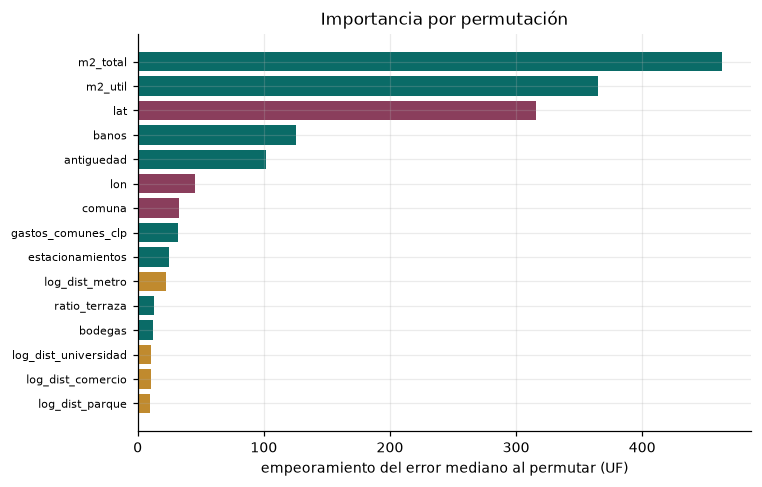

In [10]:
from sklearn.inspection import permutation_importance

# Importancia por permutacion sobre el conjunto de PRUEBA: mide cuanto empeora la
# prediccion al desordenar cada variable. A diferencia de la importancia interna
# del arbol, no premia a las variables con muchos valores distintos.
muestra = np.random.default_rng(SEMILLA).choice(len(X_test), min(1500, len(X_test)),
                                                replace=False)
imp = permutation_importance(modelo_final, X_test.iloc[muestra], y_test[muestra],
                             n_repeats=5, random_state=SEMILLA, n_jobs=1,
                             scoring="neg_median_absolute_error")
orden = pd.Series(imp.importances_mean, index=X_test.columns).sort_values(ascending=False)

BLOQUE = {**{c: "estructural" for c in ESTRUCTURALES},
          **{c: "ubicacion" for c in UBICACION_NUM + UBICACION_CAT},
          **{c: "vecindario" for c in VECINDARIO}}

print("=== las 15 variables mas influyentes ===")
for v, s in orden.head(15).items():
    print(f"  {s:>8.1f} UF   [{BLOQUE.get(v,'?'):<12}] {v}")

por_bloque = orden.groupby(orden.index.map(BLOQUE)).sum().sort_values(ascending=False)
print("\n=== aporte total por bloque hedonico ===")
for b, s in por_bloque.items():
    print(f"  {b:<14} {s:>8.1f} UF   ({100*s/por_bloque.sum():.0f}%)")

fig, ax = plt.subplots(figsize=(7, 4.5))
top = orden.head(15)[::-1]
ax.barh(range(len(top)), top.to_numpy(),
        color=[COLORES[["estructural","ubicacion","vecindario"].index(BLOQUE.get(v,"estructural"))]
               for v in top.index])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
ax.set_xlabel("empeoramiento del error mediano al permutar (UF)")
ax.set_title("Importancia por permutación")
plt.tight_layout(); plt.show()

## Paso 8 — El rango esperado, no un número solo

Decir «esta propiedad vale 3.450 UF» es falsa precisión. El producto necesita un **rango**: entre
cuánto y cuánto es razonable que se pida.

Se entrenan dos modelos más con **regresión cuantílica** —percentiles 10 y 90—. En teoría el
intervalo entre ambos debería contener el precio real el 80 % de las veces.

**En la práctica no lo hace.** La regresión cuantílica sola suele quedar mal calibrada fuera de
muestra: al medirla aquí, el intervalo 10–90 cubría solo el **68 %**. Prometer un rango que falla
una de cada tres veces sería peor que no dar rango.

Por eso se aplica encima una **calibración conforme** (Romano et al., *Conformalized Quantile
Regression*, NeurIPS 2019). La idea es simple: se aparta un trozo del entrenamiento que los modelos
cuantílicos **no ven**, se mide en él cuánto se quedan cortos, y se ensancha el intervalo en esa
cantidad. Eso garantiza la cobertura del 80 % en muestra finita, sin suponer nada sobre la
distribución del error.

El corte de calibración respeta los **grupos de edificio**, igual que la división principal: si un
departamento de la torre quedara en el propio-entrenamiento y otro en la calibración, la garantía se
rompería.

propio-entrenamiento 5,928 · calibracion 1,924



  cuantil 10% entrenado


  cuantil 90% entrenado

correccion conforme: 195 UF (el intervalo se ensancha esa cantidad a cada lado)



                            cobertura   ancho mediano
------------------------------------------------------
cuantilica sola                 66.1%             28%
+ calibracion conforme          78.7%             39%
objetivo                          80%

El intervalo se ensancha, que es el precio de que la cobertura sea real.


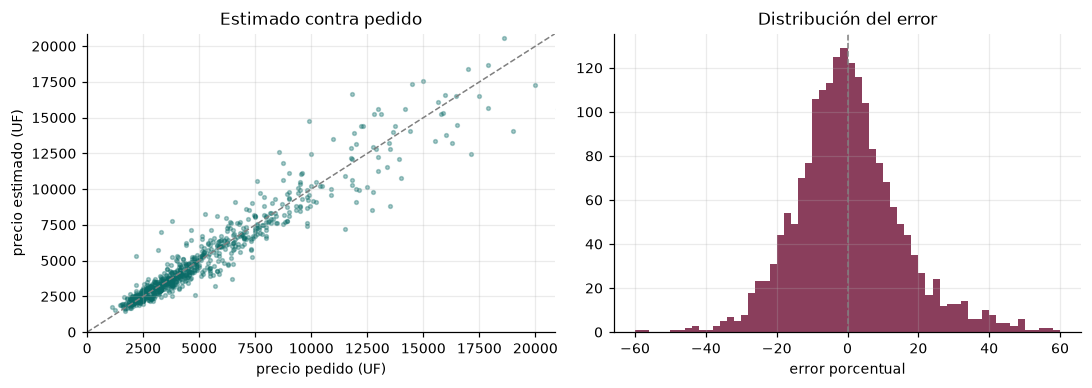

In [11]:
ALFA = 0.20   # se busca 1-ALFA = 80% de cobertura

# El entrenamiento se parte en propio-train (75%) y calibracion (25%), respetando
# los edificios: si una torre quedara en ambos, la garantia conforme se rompe.
sep_cal = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEMILLA)
i_prop, i_cal = next(sep_cal.split(X_train, y_train,
                                   groups=datos.loc[i_train, "edificio"]))
X_prop, y_prop = X_train.iloc[i_prop], y_train[i_prop]
X_cal, y_cal = X_train.iloc[i_cal], y_train[i_cal]
print(f"propio-entrenamiento {len(i_prop):,} · calibracion {len(i_cal):,}\n")

cuantiles = {}
for q in (ALFA / 2, 1 - ALFA / 2):
    m = envolver(HistGradientBoostingRegressor(
        loss="quantile", quantile=q, max_iter=400, learning_rate=0.06,
        max_leaf_nodes=31, min_samples_leaf=20, random_state=SEMILLA), False)
    m.fit(X_prop, y_prop)
    cuantiles[q] = m
    print(f"  cuantil {q:.0%} entrenado")

Q_BAJO, Q_ALTO = ALFA / 2, 1 - ALFA / 2

# --- Calibracion conforme ----------------------------------------------------
# E_i mide cuanto se quedo corto el intervalo en cada caso de calibracion:
# positivo si el valor real cayo fuera, negativo si cayo comodamente dentro.
lo_cal = cuantiles[Q_BAJO].predict(X_cal)
hi_cal = cuantiles[Q_ALTO].predict(X_cal)
E = np.maximum(lo_cal - y_cal, y_cal - hi_cal)
n_cal = len(E)
k = int(np.ceil((n_cal + 1) * (1 - ALFA)))
CORRECCION = float(np.sort(E)[min(k, n_cal) - 1])
print(f"\ncorreccion conforme: {CORRECCION:,.0f} UF "
      f"(el intervalo se ensancha esa cantidad a cada lado)")


def intervalo(entrada):
    """Rango esperado, ya calibrado."""
    lo = cuantiles[Q_BAJO].predict(entrada) - CORRECCION
    hi = cuantiles[Q_ALTO].predict(entrada) + CORRECCION
    return np.maximum(lo, 0), hi


# --- Comprobacion en el conjunto de prueba -----------------------------------
p10_sc = cuantiles[Q_BAJO].predict(X_test)
p90_sc = cuantiles[Q_ALTO].predict(X_test)
cob_sin = 100 * np.mean((y_test >= p10_sc) & (y_test <= p90_sc))

p10, p90 = intervalo(X_test)
dentro = (y_test >= p10) & (y_test <= p90)
cob_con = 100 * dentro.mean()

print(f"\n{'':<26}{'cobertura':>11}{'ancho mediano':>16}")
print("-" * 54)
print(f"{'cuantilica sola':<26}{cob_sin:>10.1f}%"
      f"{np.median(100*(p90_sc-p10_sc)/pred_test):>15.0f}%")
print(f"{'+ calibracion conforme':<26}{cob_con:>10.1f}%"
      f"{np.median(100*(p90-p10)/pred_test):>15.0f}%")
print(f"{'objetivo':<26}{100*(1-ALFA):>10.0f}%")
print("\nEl intervalo se ensancha, que es el precio de que la cobertura sea real.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
s = np.random.default_rng(SEMILLA).choice(len(y_test), min(800, len(y_test)), replace=False)
a1.scatter(y_test[s], pred_test[s], s=6, alpha=0.35, color=COLORES[0])
lim = [0, np.percentile(y_test, 99)]
a1.plot(lim, lim, "--", color="gray", lw=1)
a1.set_xlim(lim); a1.set_ylim(lim)
a1.set_xlabel("precio pedido (UF)"); a1.set_ylabel("precio estimado (UF)")
a1.set_title("Estimado contra pedido")

a2.hist(100 * (pred_test - y_test) / y_test, bins=60, range=(-60, 60), color=COLORES[1])
a2.axvline(0, color="gray", ls="--", lw=1)
a2.set_xlabel("error porcentual"); a2.set_title("Distribución del error")
plt.tight_layout(); plt.show()

## Paso 9 — La función del producto

Esta es la pieza que consumirá el backend. Recibe los atributos de una propiedad más el precio que
pide el aviso, y devuelve el veredicto.

**Sobre el umbral.** La clasificación no usa números redondos arbitrarios sino el **error propio del
modelo**: si el MdAPE es del 8 %, una diferencia del 5 % entre lo pedido y lo estimado no significa
nada —es ruido—. Solo a partir de aproximadamente un error típico la diferencia empieza a ser señal.
Por eso los cortes se expresan en múltiplos del MdAPE.

In [12]:
MDAPE_MODELO = float(tabla.loc[GANADOR, "MdAPE"])


def evaluar_propiedad(atributos: dict, precio_pedido_uf: float | None = None) -> dict:
    """Estima el precio de una propiedad y juzga el precio pedido.

    `atributos` acepta las columnas crudas del dataset (m2_util, dormitorios,
    banos, comuna, lat, lon, tipo...) y, opcionalmente, `servicios_cercanos`
    como el JSON que devuelve la API de Places. Lo que falte queda en NaN y el
    modelo lo maneja.
    """
    fila = pd.DataFrame([atributos])
    for c in NUMERICAS + ["servicios_cercanos", "tipo", "comuna"]:
        if c not in fila.columns:
            fila[c] = np.nan
    fila = construir_features(fila)
    for c in TODAS:
        if c not in fila.columns:
            fila[c] = np.nan
    entrada = fila[TODAS]

    estimado = float(modelo_final.predict(entrada)[0])
    lo, hi = intervalo(entrada)
    rango = (float(lo[0]), float(hi[0]))

    salida = {
        "precio_estimado_uf": round(estimado),
        "rango_esperado_uf": (round(rango[0]), round(rango[1])),
        "error_tipico_modelo_pct": round(MDAPE_MODELO, 1),
    }
    if precio_pedido_uf is None:
        return salida

    brecha = 100 * (precio_pedido_uf - estimado) / estimado
    z = brecha / MDAPE_MODELO          # la brecha medida en errores tipicos

    if   z <= -2.0: veredicto, detalle = "MUY BARATO", "muy por debajo de lo esperado"
    elif z <= -1.0: veredicto, detalle = "BARATO", "bajo el precio de mercado"
    elif z <   1.0: veredicto, detalle = "EN PRECIO", "dentro del rango de mercado"
    elif z <   2.0: veredicto, detalle = "CARO", "sobre el precio de mercado"
    else:           veredicto, detalle = "MUY CARO", "muy por encima de lo esperado"

    # Puntaje 0-100: 50 es pagar justo lo estimado, 100 una ganga, 0 un despropósito.
    puntaje = float(np.clip(50 - brecha * 1.5, 0, 100))

    salida.update({
        "precio_pedido_uf": round(precio_pedido_uf),
        "brecha_pct": round(brecha, 1),
        "veredicto": veredicto,
        "detalle": detalle,
        "puntaje": round(puntaje),
        "dentro_del_rango": bool(rango[0] <= precio_pedido_uf <= rango[1]),
    })
    return salida


print(f"umbral en uso: 1 error tipico = {MDAPE_MODELO:.1f}% de brecha")
print(f"  EN PRECIO   : brecha menor a +-{MDAPE_MODELO:.1f}%")
print(f"  BARATO/CARO : entre {MDAPE_MODELO:.1f}% y {2*MDAPE_MODELO:.1f}%")
print(f"  MUY ...     : sobre {2*MDAPE_MODELO:.1f}%")

umbral en uso: 1 error tipico = 8.8% de brecha
  EN PRECIO   : brecha menor a +-8.8%
  BARATO/CARO : entre 8.8% y 17.6%
  MUY ...     : sobre 17.6%


In [13]:
# Se prueba con propiedades REALES del conjunto de prueba, que el modelo nunca vio
muestras = prueba.sample(3, random_state=7)

for _, p in muestras.iterrows():
    atributos = {c: p[c] for c in ["m2_util", "m2_total", "dormitorios", "banos",
                                   "estacionamientos", "bodegas", "ano_construccion",
                                   "gastos_comunes_clp", "lat", "lon", "comuna",
                                   "tipo", "servicios_cercanos"]}
    r = evaluar_propiedad(atributos, float(p["precio_uf"]))
    print(f"\n{'='*70}")
    print(f"{p['tipo']} en {p['comuna']} · {p['m2_util']:.0f} m² · "
          f"{p['dormitorios'] if pd.notna(p['dormitorios']) else '?'} dorm")
    if pd.notna(p["servicios_cercanos"]) and p["servicios_cercanos"] != "SIN_DATO":
        sv = json.loads(p["servicios_cercanos"])
        print(f"   metro a {sv['metro']['mas_cercano_m']} m ({sv['metro']['nombre']})")
    print(f"{'='*70}")
    print(f"   precio pedido    : {r['precio_pedido_uf']:>7,} UF")
    print(f"   precio estimado  : {r['precio_estimado_uf']:>7,} UF")
    print(f"   rango esperado   : {r['rango_esperado_uf'][0]:,} - "
          f"{r['rango_esperado_uf'][1]:,} UF")
    print(f"   brecha           : {r['brecha_pct']:>+7.1f}%")
    print(f"   VEREDICTO        : {r['veredicto']}  ({r['detalle']})")
    print(f"   puntaje          : {r['puntaje']}/100")


departamento en nunoa · 96 m² · 3.0 dorm
   metro a 396 m (Estadio Nacional)
   precio pedido    :   8,500 UF
   precio estimado  :   8,143 UF
   rango esperado   : 7,013 - 8,362 UF
   brecha           :    +4.4%
   VEREDICTO        : EN PRECIO  (dentro del rango de mercado)
   puntaje          : 43/100



casa en la-florida · 186 m² · 6.0 dorm
   metro a 5582 m (Quilín)
   precio pedido    :  11,290 UF
   precio estimado  :  11,957 UF
   rango esperado   : 11,041 - 13,788 UF
   brecha           :    -5.6%
   VEREDICTO        : EN PRECIO  (dentro del rango de mercado)
   puntaje          : 58/100



departamento en san-miguel · 50 m² · ? dorm
   metro a 377 m (Lo Vial)
   precio pedido    :   3,050 UF
   precio estimado  :   3,173 UF
   rango esperado   : 2,589 - 3,707 UF
   brecha           :    -3.9%
   VEREDICTO        : EN PRECIO  (dentro del rango de mercado)
   puntaje          : 56/100


In [14]:
# Como clasifica el modelo a las 1.900 propiedades del conjunto de prueba.
# Casi todas deberian caer en EN PRECIO: son avisos reales del mercado, no gangas.
brechas = 100 * (y_test - pred_test) / pred_test
z = brechas / MDAPE_MODELO
etiquetas = pd.cut(z, [-np.inf, -2, -1, 1, 2, np.inf],
                   labels=["MUY BARATO", "BARATO", "EN PRECIO", "CARO", "MUY CARO"])
conteo = etiquetas.value_counts().reindex(
    ["MUY BARATO", "BARATO", "EN PRECIO", "CARO", "MUY CARO"])

print("clasificacion de las propiedades del conjunto de prueba:")
for k, v in conteo.items():
    barra = "#" * int(40 * v / conteo.max())
    print(f"  {k:<12} {v:>5,} ({100*v/len(z):>4.1f}%)  {barra}")
print(f"\nEl grueso cae en EN PRECIO, que es lo esperable: son avisos reales de")
print("un mercado en equilibrio, no una muestra de oportunidades.")

clasificacion de las propiedades del conjunto de prueba:
  MUY BARATO     172 ( 8.8%)  #######
  BARATO         290 (14.8%)  ###########
  EN PRECIO      967 (49.3%)  ########################################
  CARO           270 (13.8%)  ###########
  MUY CARO       261 (13.3%)  ##########

El grueso cae en EN PRECIO, que es lo esperable: son avisos reales de
un mercado en equilibrio, no una muestra de oportunidades.


## Paso 10 — Guardar para el despliegue

Se serializa todo lo que la API va a necesitar: el modelo, los dos cuantiles, la lista de variables
en su orden exacto y las métricas con las que se calibran los umbrales.

El JSON hermano deja registrado con qué datos y con qué resultados se entrenó, que es lo que permite
reproducir o auditar la versión desplegada.

In [15]:
from datetime import datetime

paquete = {
    "modelo": modelo_final,
    "cuantil_bajo": cuantiles[Q_BAJO],
    "cuantil_alto": cuantiles[Q_ALTO],
    "correccion_conforme": CORRECCION,
    "alfa": ALFA,
    "columnas": TODAS,
    "categorias_poi": CATEGORIAS_POI,
    "mdape": MDAPE_MODELO,
    "uf_referencia": UF,
    "anio_referencia": ANIO,
}
ruta = MODELOS / "venta.joblib"
joblib.dump(paquete, ruta)

ficha = {
    "objetivo": "precio_uf", "operacion": "venta",
    "fecha": datetime.now().isoformat(timespec="seconds"),
    "algoritmo": GANADOR,
    "n_total": int(len(X)), "n_train": int(len(i_train)), "n_test": int(len(i_test)),
    "division": "80/20 agrupado por edificio (GroupShuffleSplit)",
    "semilla": SEMILLA,
    "metricas_test": {k: round(float(v), 3) for k, v in tabla.loc[GANADOR].items()},
    "cobertura_intervalo_80": round(float(cob_con), 1),
    "cobertura_sin_calibrar": round(float(cob_sin), 1),
    "variables": {"estructurales": ESTRUCTURALES, "ubicacion": UBICACION_NUM + UBICACION_CAT,
                  "vecindario": VECINDARIO},
    "comparacion_modelos": tabla.reset_index().to_dict("records"),
    "sesgos_declarados": [
        "Precios de publicacion, no de cierre: en Chile el sesgo tipico es 5-15% "
        "sobre el precio final. El modelo estima precio pedido esperado.",
        "Fuente unica (portalinmobiliario) en venta: sin validacion externa posible.",
        "Foto de 15 dias: no capta tendencia temporal ni plusvalia.",
        "Las categorias comercio, salud y educacion son proxies de densidad, no "
        "malls, hospitales ni colegios en sentido estricto.",
    ],
}
(MODELOS / "venta.json").write_text(
    json.dumps(ficha, indent=2, ensure_ascii=False, default=str), encoding="utf-8")

print(f"modelo : {ruta}  ({ruta.stat().st_size/1e6:.1f} MB)")
print(f"ficha  : {MODELOS/'venta.json'}")

# Comprobacion de que lo guardado funciona al recargarse
p = joblib.load(ruta)
prueba_carga = p["modelo"].predict(X_test.iloc[[0]])[0]
print(f"\nverificacion de recarga: {prueba_carga:,.0f} UF "
      f"(esperado {pred_test[0]:,.0f})  "
      f"{'OK' if abs(prueba_carga-pred_test[0]) < 1 else 'DIFIERE'}")

modelo : modelos\venta.joblib  (4.8 MB)
ficha  : modelos\venta.json



verificacion de recarga: 15,722 UF (esperado 15,722)  OK


---

## Qué sigue

1. **El modelo de arriendo**, con las mismas variables y el mismo esquema, sobre `precio_clp`. Con
   él se calcula el yield: cuánto del dividendo cubriría el arriendo.
2. **La API en DigitalOcean**: `modelos/venta.joblib` ya contiene todo lo necesario, y
   `evaluar_propiedad()` es literalmente el cuerpo del endpoint.
3. **SHAP**, para que el informe explique *por qué* esa estimación: cuánto suma la superficie,
   cuánto la comuna, cuánto el metro a 300 metros.
4. **El crecimiento del sector**, que es lo más difícil: exige datos que este dataset no tiene
   —permisos de edificación, proyectos aprobados, series de precios—. Con una foto de 15 días no se
   puede estimar plusvalía, y conviene decirlo antes de prometerlo.